
--- 피벗 테이블 결과 ---
   mallName    평균가격  상품수
0      11번가  1077.5    4
1    159컴퍼니  1100.0    1
2  DayThree  1150.0    1
3      EK철물   880.0    1
4       G마켓   999.0   10


C:\Users\miran\AppData\Local\Temp\ipykernel_113780\3424062395.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mall_pivot.sort_values('평균가격', ascending=False),


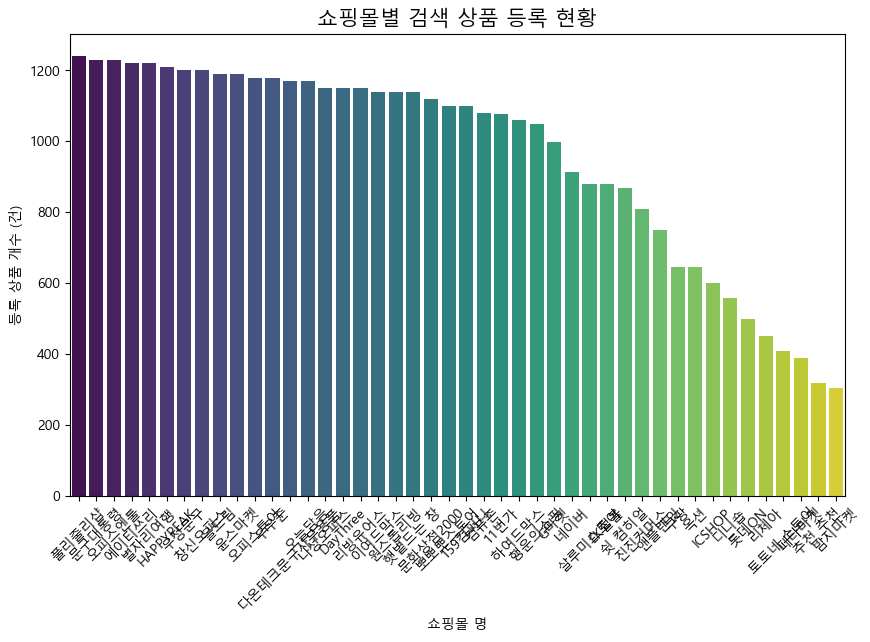

--- 카테고리별 검색 결과 요약 ---


C:\Users\miran\AppData\Local\Temp\ipykernel_113780\3424062395.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_counts,


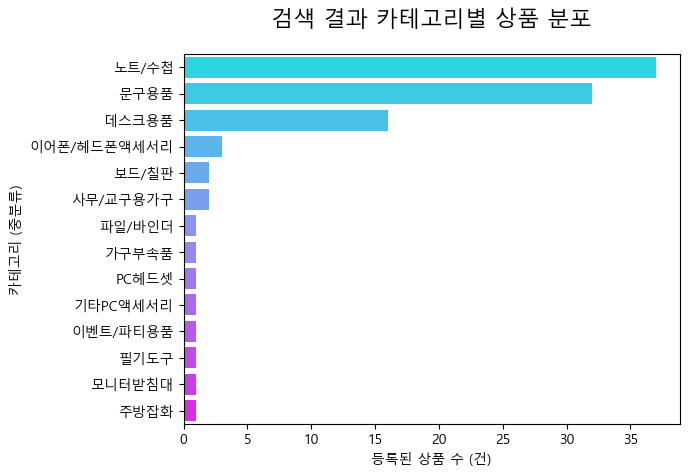

In [24]:
#🟢네이버 블로그, 쇼핑 제목으로 트랜드 파악 //search/**	검색API
# 둘 다 실행시"sort":"asc"를 빼거나 맞춰서 "sim"으로 바꾸기
import requests
import pandas as pd

# 1. 네이버 개발자 센터에서 발급받은 '도장' 준비
client_id = "FO94sqAIv4XrxJoV7qSf"
client_secret = "jfkOOP5NuM"

def get_naver_search(category, query, display=100): #함수 선언
    url = f"https://openapi.naver.com/v1/search/{category}.json"
    headers = {
        "X-Naver-Client-Id": client_id,
        "X-Naver-Client-Secret": client_secret
    }
    # "sort":"🔴asc"오름차순(최저가순) / 🔴sim 유사도순 (블로그)
    params = {"query": query, "display": display, "sort":"asc"}
    
    response = requests.get(url, headers=headers, params=params)
    return pd.DataFrame(response.json()['items'])

# 1️⃣🍋블로그 검색: 우리 공사 관련 최신 여론 확인
# df_blog = get_naver_search("blog", "한국전력 에너지절약") #함수 사용
# print("--- 블로그 검색 결과 ---")
# print(df_blog[['title', 'link']].head())

# 2️⃣🍋쇼핑 검색: 관련 물품 최저가 동향 (자산 구입 시 참고)
df_shop = get_naver_search("shop", "사무용 모니터")
# df_shop
# print("\n--- 쇼핑 검색 결과 ---")
# print(df_shop[['title', 'lprice', 'mallName']].head()) #여러개 부를 때 [[],[],[]]

# 🛑4️⃣데이터 정제부분
df_shop['title'] = df_shop['title'].str.replace('<b>', '', regex=False)
df_shop['title'] = df_shop['title'].str.replace('</b>', '', regex=False)
df_shop['lprice'] = pd.to_numeric(df_shop['lprice']) # 가격을 숫자형으로 변환
df_shop

# 🟢몰네임별로 가격의 평균(mean)과 상품 개수(count)를 집계
mall_pivot = df_shop.pivot_table(index='mallName', #기준점
                            values='lprice', #계산 대상
                            aggfunc=['mean', 'count']) #계산 방법
# Aggregate Function 우리말로는 '집계 함수' sum, max
# 컬럼명 정리 (보기 좋게)
mall_pivot.columns = ['평균가격', '상품수']
mall_pivot = mall_pivot.reset_index()

print("\n--- 피벗 테이블 결과 ---")
print(mall_pivot.head()) #.head()

# 4️⃣시각화: 평균가격('🟢상품 수'로 바꿔보기) 순서대로 정렬해서 그리기
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc('font', family='Malgun Gothic')
plt.figure(figsize=(10, 6))
sns.barplot(data=mall_pivot.sort_values('평균가격', ascending=False), 
            x='mallName', y='평균가격', palette='viridis')
plt.title('쇼핑몰별 검색 상품 등록 현황', fontsize=15)
plt.xlabel('쇼핑몰 명')
plt.ylabel('등록 상품 개수 (건)')
plt.xticks(rotation=45)
plt.show()

# 5️⃣2. category3(중분류)별로 상품이 몇 개인지 집계
# 'category3' 열에 들어있는 이름들이 각각 몇 번 등장하는지 센다!
category_counts = df_shop['category3'].value_counts().reset_index()
# 2. 컬럼명 정리
category_counts.columns = ['카테고리', '상품수']
# 3. 상품 수 순서대로 정렬 (내림차순)
category_counts = category_counts.sort_values('상품수', ascending=False)
print("--- 카테고리별 검색 결과 요약 ---")
# print(category_counts)
import matplotlib.pyplot as plt
import seaborn as sns

# 가로 막대 그래프 그리기 (x와 y를 바꾸면 됩니다)
sns.barplot(data=category_counts, 
            x='상품수', 
            y='카테고리', 
            palette='cool')

plt.title('검색 결과 카테고리별 상품 분포', fontsize=16, pad=20)
plt.xlabel('등록된 상품 수 (건)')
plt.ylabel('카테고리 (중분류)')

plt.show()

In [23]:
cols = ['title', 'lprice', 'mallName'] # 1. 뽑고 싶은 명단을 리스트로 만든다.
df_shop[cols]                          # 2. 그 명단을 판다스에 넣는다.

df_shop[['title', 'lprice', 'mallName']] # 그래서 대괄호가 겹치게 됩니다!

,title,lprice,mallName
0,투명 클립 집게 1호 2호 모니터 서류 문서 사무용 종이 메모 책고정집게 집개 클립 핀,190,밤지마켓
1,투명 클립 집게 1호 2호 모니터 서류 문서 사무용 종이 메모 책고정집게 집개 클립 핀,190,옥션
2,투명 클립 집게 1호 2호 모니터 서류 문서 사무용 종이 메모 책고정집게 집개 클립 핀,190,네이버
3,스틸 불독 집게 책 사무용 페이퍼 클립 서류 종이 문구 크립 모니터 문서 악보 파일...,260,네이버
4,스틸 불독 집게 책 사무용 페이퍼 클립 서류 종이 문구 크립 모니터 문서 악보 파일...,260,리체아
...,...,...,...
95,3M 포스트잇 강력접착 SSN 656 새싹그린(5766),1240,G마켓
96,그레이 모니터 책상 테이블 부착 펜꽂이 직사각형,1250,네이버
97,사무용 인덱스 접착 메모지 서류 구분 메모잇 메모수첩 모니터메모 미니접착메모지,1250,네이버
98,3M 포스트잇 653-2 노랑 러블리핑크 51x38mm 200매입,1250,오피스핫딜
